# Create ROIs for template matching

This notebook is used to define and save the ROIs used in the template-matching workflow. The ROIs are saved to `results/roi_by_tilt.json` and later loaded in the template-matching notebook.

This notebook should only be rerun when the ROI positions need to be changed.

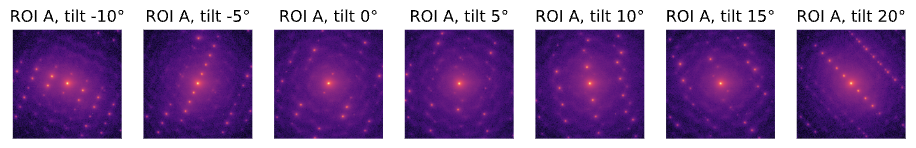
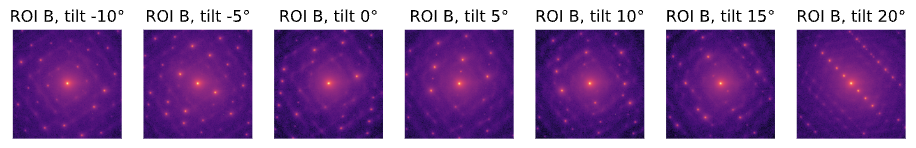

In [ ]:
%matplotlib widget

from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

import hyperspy.api as hs

import sys
import importlib

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.roi_utils as roi_utils

importlib.reload(roi_utils)

from src.roi_utils import (
    load_rois,
    save_rois_by_tilt,
)

In [ ]:
results_path = Path("../results")
results_path.mkdir(parents=True, exist_ok=True)

base_directory = Path("path/to/your/data")

roi_path = results_path / "roi_by_tilt.json"


roi_colors = {
    "A": "red",
    "B": "aqua",
    "C": "mediumorchid",
    "D": "hotpink",
}

# Load the tilt-series data

In [ ]:
# load data from 7 tilts
datasets = [
    {"tilt": +15, "path": Path("path/to/+15/data.zspy")},
    {"tilt": +10, "path": Path("path/to/+10/data.zspy")},
    {"tilt": +5,  "path": Path("path/to/+5/data.zspy")},
    {"tilt": 0,   "path": Path("path/to/0/data.zspy")},
    {"tilt": -5,  "path": Path("path/to/-5/data.zspy")},
    {"tilt": -10, "path": Path("path/to/-10/data.zspy")},
]

In [ ]:
lazy = True
signals = {}

for dataset in datasets:

    tilt = dataset["tilt"]
    path = dataset["path"]

    print(f"Loading tilt {tilt}")

    signal = hs.load(
        str(path),
        lazy=lazy,
    )

    if lazy:
        signal.rechunk(
            nav_chunks=(32, 32),
            sig_chunks=(32, 32),
        )

    print(f"  shape={signal.data.shape}, dtype={signal.data.dtype}")

    signals[tilt] = signal

# Define ROIs interactively

As the different datasets differ from tilt to tilt, all the rois need to be interactively set. Use the diffraction signal to distinguish between twin domains.

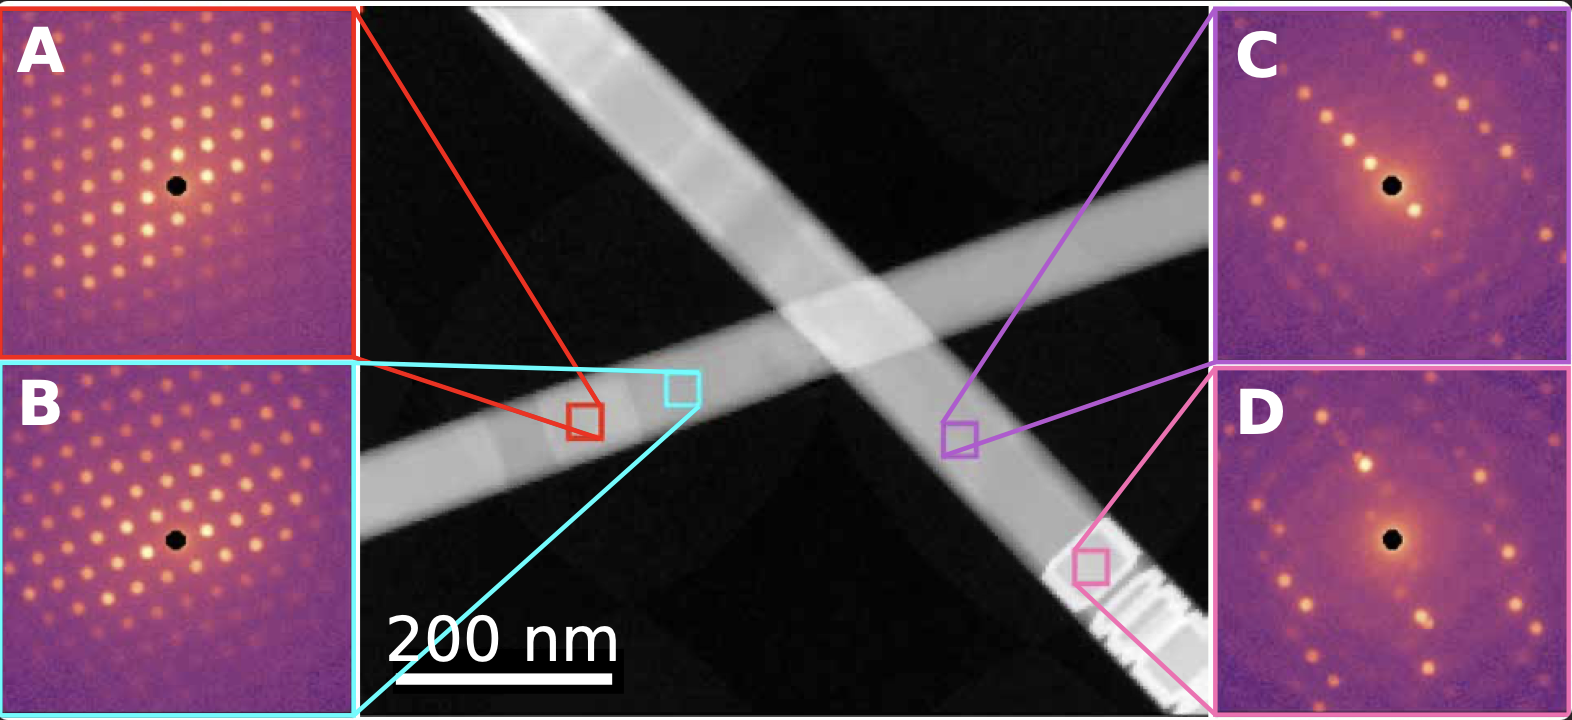

In [ ]:
roi_by_tilt = {}

for tilt, signal in signals.items():

    print(f"\n Tilt {tilt}")

# rois defined by visual inspection of the data
    roi_A = hs.roi.RectangularROI(left=92.0, right=98.0, top=206.0, bottom=212.0)
    roi_B = hs.roi.RectangularROI(left=82.0, right=89.0, top=192.0, bottom=199.0)
    roi_C = hs.roi.RectangularROI(left=87.0, right=93.0, top=84.0, bottom=91.0)
    roi_D = hs.roi.RectangularROI(left=93.0, right=99.0, top=70.0, bottom=76.0)

    signal.plot(norm="symlog")

    roi_A.add_widget(signal, color="red")
    roi_B.add_widget(signal, color="aqua")
    roi_C.add_widget(signal, color="mediumorchid")
    roi_D.add_widget(signal, color="hotpink")

    roi_by_tilt[tilt] = {
        "A": roi_A,
        "B": roi_B,
        "C": roi_C,
        "D": roi_D
    }

In [ ]:
roi_by_tilt = load_rois(roi_path)

for tilt, signal in signals.items():

    print(f"Tilt {tilt}")

    # plot dataset
    signal.plot(norm="symlog")

    rois = roi_by_tilt[tilt]

    # add overlays
    for key, roi in rois.items():
        roi.add_widget(signal, color=roi_colors[key])

# Save ROIs to JSON

In [ ]:
save_rois_by_tilt(
    roi_by_tilt,
    roi_path,
)

print(f"Saved ROIs to: {roi_path}")